# Percentile Forecast Optimization

This notebook focuses on percentile-based forecasts: each percentile forecast already
embeds its own buffer, so the policy uses `NullSafetyStockStrategy()` (no additional
safety stock is layered on top) and the article-level tuning question is *which
percentile target minimizes cost*, not *how much extra buffer to add*.

**Scope note (Task 14 rewrite):** janrth's original notebook also swept an aggregation
window via `optimize_aggregation_and_forecast_targets`, which was never ported into this
repo (see `io_.py`'s module docstring) -- dropped here. `calibration.optimize` is reused
to pick the best percentile target per article, since it's generic over any hashable
candidate value, not just a numeric factor.

In [1]:
import pandas as pd
import random
from dataclasses import replace

from replenishment.io_ import (
    generate_standard_simulation_rows, standard_simulation_rows_to_dataframe,
    split_standard_simulation_rows, replenishment_decision_rows_to_dataframe,
    ReplenishmentDecisionRow,
)
from replenishment.calibration import optimize
from replenishment.simulation import simulate_replenishment
from replenishment.policy import ReplenishmentPolicy
from replenishment.timeseries import TimeSeries
from replenishment.strategies.multiplier import NullSafetyStockStrategy
from replenishment.viz import plot_replenishment_decisions

### Policy cadence parameters

In [2]:
review_period = 3
forecast_horizon = 3

## Generate Sample Data

In [3]:
history_mean = 18
history_std = 10
forecast_mean = 17
forecast_std = 2
replenishment_start_period = 90

rows = generate_standard_simulation_rows(
    n_unique_ids=3,
    periods=120,
    forecast_start_period=replenishment_start_period,
    history_mean=history_mean,
    history_std=history_std,
    forecast_mean=forecast_mean,
    forecast_std=forecast_std,
    initial_on_hand=15,
    current_stock=15,
    lead_time=3,
    seed=7,
    holding_cost_per_unit=1,
    stockout_cost_per_unit=100,
    order_cost_per_order=10,
    percentile_multipliers={
        "p10": 0.6, "p20": 0.70, "p30": 0.80, "p40": 0.90, "p50": 1.0,
        "p60": 1.10, "p70": 1.20, "p80": 1.30, "p90": 1.40,
    },
)
df = standard_simulation_rows_to_dataframe(rows, library="pandas")

## Split Backtest vs Forecast

In [4]:
backtest_rows, forecast_rows = split_standard_simulation_rows(rows)

# Add simulated actuals for the forecast/replenishment period so we can measure lost sales.
rng = random.Random(7)
def _sample_int(mean: float, std: float) -> int:
    return max(0, int(round(rng.gauss(mean, std))))

forecast_rows = [
    replace(row, actuals=_sample_int(history_mean, history_std), demand=_sample_int(history_mean, history_std))
    for row in forecast_rows
]

# Rebuild df so plots include actuals in the replenishment period.
df = standard_simulation_rows_to_dataframe(backtest_rows + forecast_rows, library="pandas")

In [5]:
def _group_by_article(rows):
    grouped = {}
    for row in rows:
        grouped.setdefault(row.unique_id, []).append(row)
    for uid in grouped:
        grouped[uid].sort(key=lambda r: r.ds)
    return grouped

## Step 1: Optimize Percentile Target (order-up-to)

In [6]:
def calibrate_and_simulate_percentiles(trigger_factory):
    backtest_by_article = _group_by_article(backtest_rows)
    forecast_by_article = _group_by_article(forecast_rows)
    decision_rows = []
    calibration_results = {}
    for unique_id, article_backtest in backtest_by_article.items():
        targets = sorted(article_backtest[0].forecast_percentiles) + ["mean"]
        demand = [r.demand for r in article_backtest]
        lead_time = article_backtest[0].lead_time

        def _series_for(target, rows):
            if target == "mean":
                return [r.forecast for r in rows]
            return [r.forecast_percentiles[target] for r in rows]

        def candidate_builder(target, article_backtest=article_backtest, lead_time=lead_time):
            return ReplenishmentPolicy(
                forecast=TimeSeries.from_values(_series_for(target, article_backtest)),
                safety_stock=NullSafetyStockStrategy(),
                trigger=trigger_factory(),
                lead_time=lead_time, review_period=review_period, forecast_horizon=forecast_horizon,
            )

        result = optimize(
            candidate_builder=candidate_builder, candidate_values=targets,
            periods=len(article_backtest), demand=demand, initial_on_hand=article_backtest[0].initial_on_hand,
            lead_time=lead_time, holding_cost_per_unit=article_backtest[0].holding_cost_per_unit,
            stockout_cost_per_unit=article_backtest[0].stockout_cost_per_unit,
            order_cost_per_order=article_backtest[0].order_cost_per_order,
        )
        calibration_results[unique_id] = result

        article_forecast_rows = forecast_by_article.get(unique_id, [])
        if not article_forecast_rows:
            continue
        eval_policy = ReplenishmentPolicy(
            forecast=TimeSeries.from_values(_series_for(result.best_value, article_forecast_rows)),
            safety_stock=NullSafetyStockStrategy(),
            trigger=trigger_factory(),
            lead_time=lead_time, review_period=review_period, forecast_horizon=forecast_horizon,
        )
        current_stock = article_forecast_rows[0].current_stock
        simulation = simulate_replenishment(
            periods=len(article_forecast_rows), demand=[r.demand for r in article_forecast_rows],
            initial_on_hand=current_stock, lead_time=lead_time, policy=eval_policy,
            holding_cost_per_unit=article_forecast_rows[0].holding_cost_per_unit,
            stockout_cost_per_unit=article_forecast_rows[0].stockout_cost_per_unit,
            order_cost_per_order=article_forecast_rows[0].order_cost_per_order,
        )
        for row, snapshot in zip(article_forecast_rows, simulation.snapshots):
            decision_rows.append(ReplenishmentDecisionRow(
                unique_id=unique_id, ds=row.ds, quantity=snapshot.order_placed,
                demand=snapshot.demand, incoming_stock=snapshot.received,
                starting_on_hand=snapshot.starting_on_hand, ending_on_hand=snapshot.ending_on_hand,
                on_order=snapshot.on_order, backorders=snapshot.backorders,
                percentile_target=result.best_value,
            ))
    decisions_df = replenishment_decision_rows_to_dataframe(decision_rows, library="pandas")
    return calibration_results, decisions_df


from replenishment.strategies.order_trigger import OrderUpToTrigger, ReorderPointTrigger

percentile_results, percentile_decision_df = calibrate_and_simulate_percentiles(OrderUpToTrigger)
{uid: result.best_value for uid, result in percentile_results.items()}

{'A': 'p90', 'B': 'p90', 'C': 'p90'}

### Plot

<Axes: title={'center': 'Percentile decisions (order-up-to)'}, xlabel='Date', ylabel='Units'>

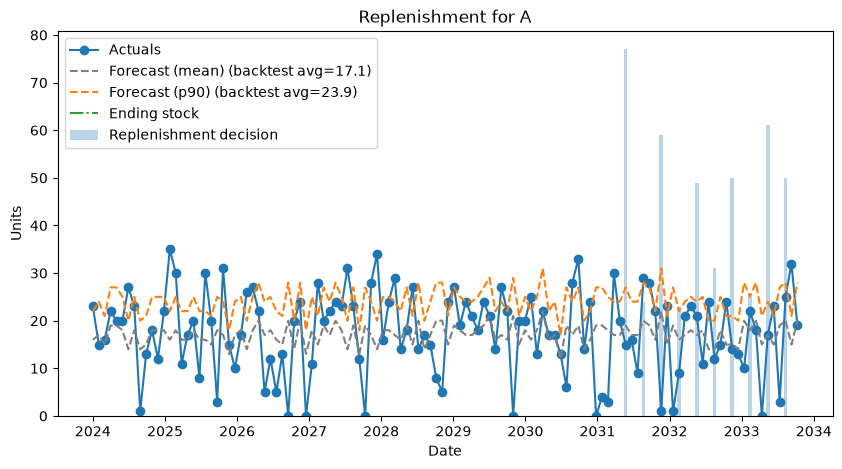

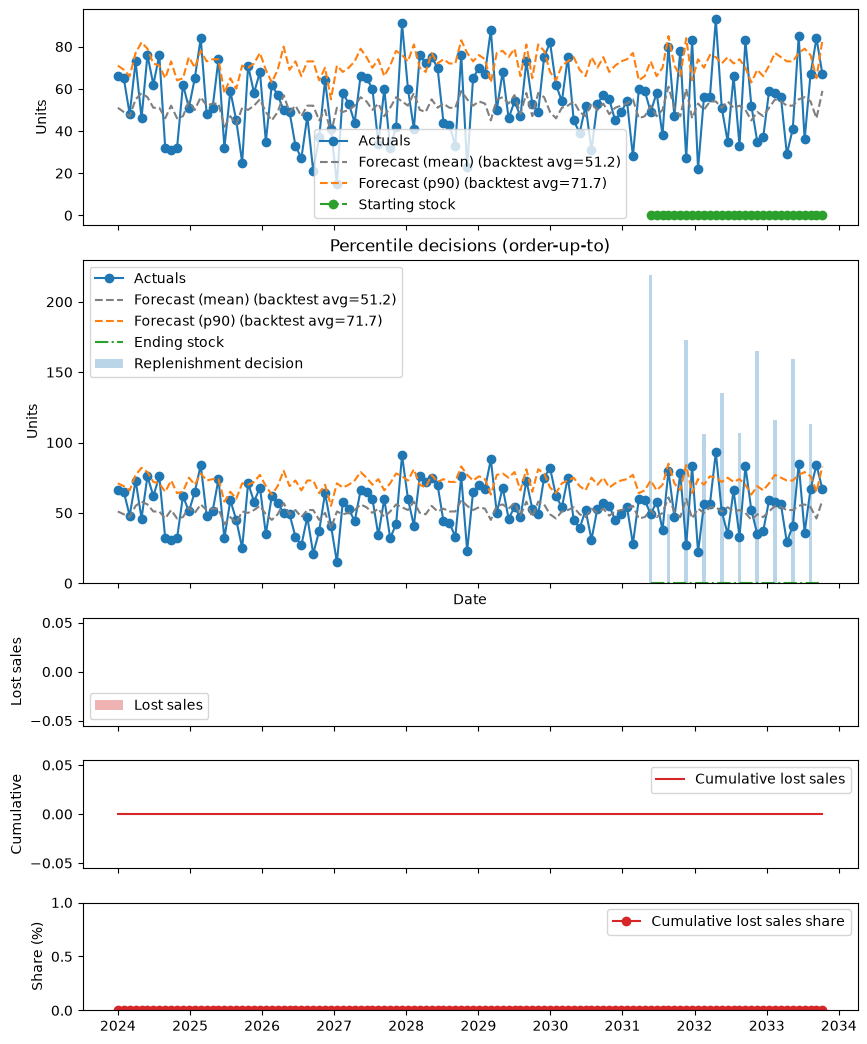

In [7]:
example_id = df["unique_id"].iloc[0]
plot_replenishment_decisions(df, percentile_decision_df, unique_id=example_id)
plot_replenishment_decisions(df, percentile_decision_df, aggregate=True, title="Percentile decisions (order-up-to)")

## ROP policy (percentile targets)
This section optimizes percentile targets using a reorder-point trigger instead.

In [8]:
rop_percentile_results, rop_percentile_decision_df = calibrate_and_simulate_percentiles(ReorderPointTrigger)
{uid: result.best_value for uid, result in rop_percentile_results.items()}

{'A': 'p80', 'B': 'p90', 'C': 'p60'}

<Axes: title={'center': 'Replenishment for A'}, xlabel='Date', ylabel='Units'>

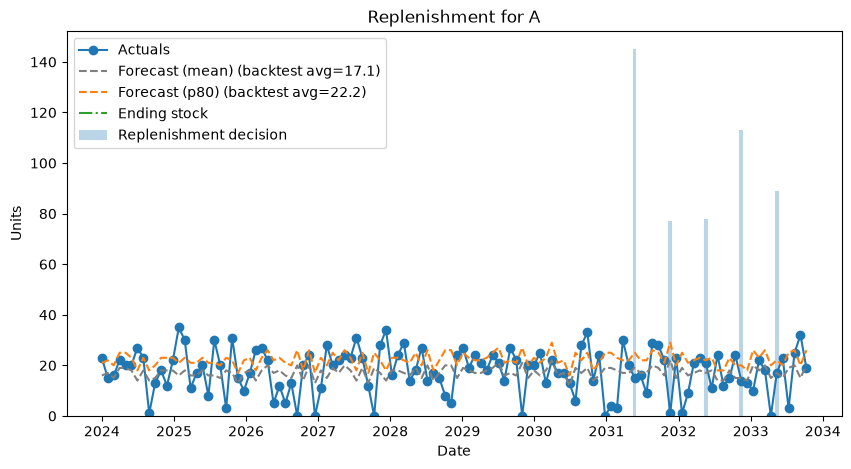

In [9]:
plot_replenishment_decisions(df, rop_percentile_decision_df, unique_id=example_id)